<a href="https://colab.research.google.com/github/olifly/Lagadeildin/blob/main/DataVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

SEASON_TO_ANALYSE = "S2"

In [2]:
# @title

base_url = f'https://raw.githubusercontent.com/olifly/Lagadeildin/main/data/{SEASON_TO_ANALYSE}/'
FILENAMES = ['competitors.csv', 'rounds.csv', 'submissions.csv', 'votes.csv']

file_urls = []
for filename in FILENAMES:
    full_url = base_url + filename
    file_urls.append(full_url)

In [3]:
# @title
dataframes = {}
DF_NAMES = ['competitors', 'rounds', 'submissions', 'votes']

for i, url in enumerate(file_urls):
    df_name = DF_NAMES[i]
    try:
        df = pd.read_csv(url)
        dataframes[df_name] = df
    except Exception as e:
        print(f"Villa við að hlaða {url}: {e}")

# Greining
# print(f"Fjöldi umferða í gögnum: {len(dataframes['rounds'])}")
# print(f"Fjöldi einstakra Round ID í atkvæðum: {dataframes['votes']['Round ID'].nunique()}")
# display(dataframes['rounds'])

In [4]:
# @title
# 1. Sameina atkvæði og innsendingar
votes_df = dataframes['votes']
submissions_df = dataframes['submissions']

votes_submissions = pd.merge(
    votes_df,
    submissions_df,
    on=['Spotify URI', 'Round ID'],
    how='inner'
)

# 2. Sameina við keppendur
merged_data = pd.merge(
    votes_submissions,
    dataframes['competitors'],
    left_on='Submitter ID',
    right_on='ID',
    how='inner'
)

# 3. Hópa eftir umferð og keppanda til að finna stig
round_results = merged_data.groupby(['Round ID', 'Submitter ID', 'Name'])['Points Assigned'].sum().reset_index()

# 4. Finna sigurvegara hverrar umferðar
round_winners = round_results.sort_values(['Round ID', 'Points Assigned'], ascending=[True, False]).groupby('Round ID').head(1).copy()

# 5. Sameina við umferðir og raða eftir upprunalegri röð
round_winners_with_names = pd.merge(
    dataframes['rounds'][['ID', 'Name']],
    round_winners,
    left_on='ID',
    right_on='Round ID',
    how='inner',
    suffixes=('_round', '')
)

# Athuga hvort umferðir vanti
found_round_ids = round_results['Round ID'].unique()
all_round_ids = dataframes['rounds']['ID'].unique()
missing_rounds = set(all_round_ids) - set(found_round_ids)

if missing_rounds:
    print(f"Varúð: {len(missing_rounds)} umferð(ir) voru undanskildar vegna vöntunar á gögnum.")

# 6. Birta niðurstöður
print('--- Sigurvegarar Umferða ---')
display(round_winners_with_names[['Name_round', 'Name', 'Points Assigned']].rename(columns={'Name_round': 'Heiti Umferðar', 'Name': 'Nafn Sigurvegara', 'Points Assigned': 'Stig'}))

# Vista fyrir næstu skref
round_standings = round_results

--- Sigurvegarar Umferða ---


,Heiti Umferðar,Nafn Sigurvegara,Stig
0,Ungir Sjálfstæðismenn,Eiríkur Stefán Ásgeirsson,45
1,Éttu skít og deyðu!!!,G-Unit,33
2,Austur Evrópa,Jóhann Ævar Grímsson,32
3,Epstein og pedófílar,G-Unit,33
4,ABE Punk,Grímur Gíslason,27


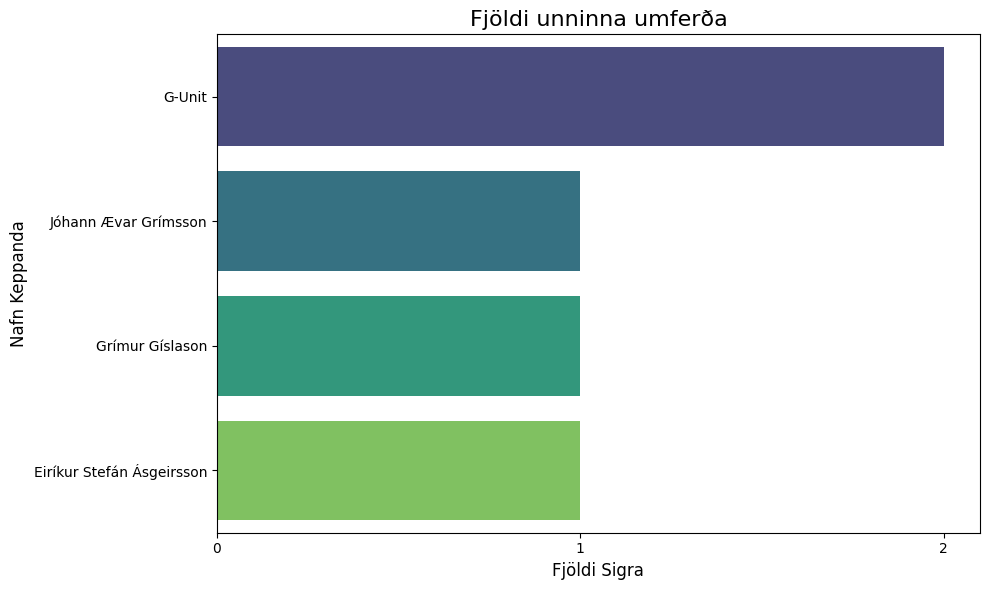

In [5]:
# @title
# 1. Telja sigra fyrir hvern keppanda
win_counts = round_winners['Name'].value_counts().reset_index()
win_counts.columns = ['Nafn', 'Fjöldi Sigra']

# 2. Teikna grafið
plt.figure(figsize=(10, 6))
sns.barplot(
    data=win_counts,
    x='Fjöldi Sigra',
    y='Nafn',
    palette='viridis',
    hue='Nafn',
    legend=False
)

# 3. Stillingar og titlar
plt.title('Fjöldi unninna umferða', fontsize=16)
plt.xlabel('Fjöldi Sigra', fontsize=12)
plt.ylabel('Nafn Keppanda', fontsize=12)

# Festa heiltölur á x-ás
from matplotlib.ticker import MaxNLocator
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [6]:
# @title
# 1. Hópa eftir nafni til að reikna heildarstig tímabilsins
season_leaderboard = round_standings.groupby(['Name', 'Submitter ID'])['Points Assigned'].sum().reset_index()

# 2. Raða eftir stigum í lækkandi röð
season_leaderboard = season_leaderboard.sort_values(by='Points Assigned', ascending=False).reset_index(drop=True)

# 3. Endurnefna dálka
season_leaderboard = season_leaderboard.rename(columns={'Name': 'Nafn', 'Points Assigned': 'Heildarstig'})

# 4. Birta niðurstöður
# print('--- Stigatafla Tímabilsins ---')
# display(season_leaderboard[['Nafn', 'Heildarstig']])

# season_leader = season_leaderboard.iloc[0]
# print(f"\nNÚVERANDI FORYSTUSAUÐUR ER: {season_leader['Nafn']} með {season_leader['Heildarstig']} stig.")

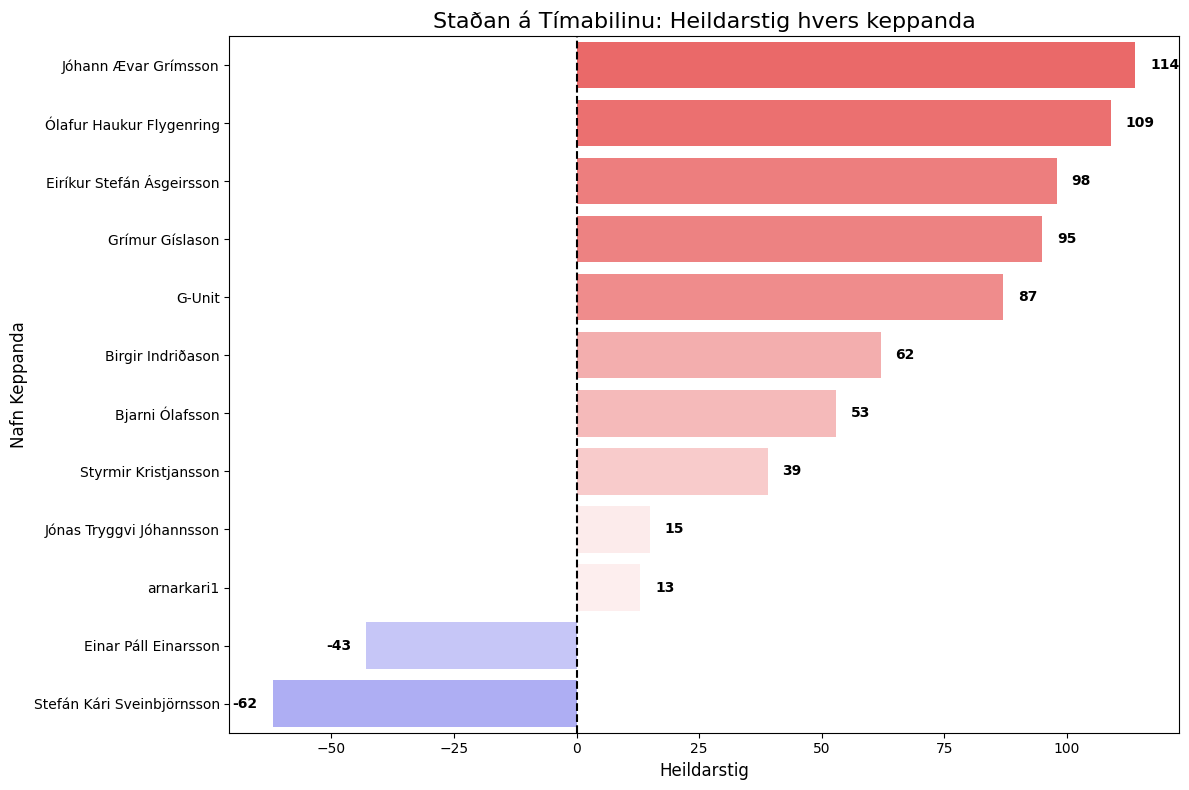

In [7]:
# @title
# 1. Litir byggðir á stigum
max_abs = max(season_leaderboard['Heildarstig'].abs().max(), 1)
color_limit = max_abs * 1.5
norm = mcolors.TwoSlopeNorm(vmin=-color_limit, vcenter=0, vmax=color_limit)
colors = [plt.cm.bwr(norm(val)) for val in season_leaderboard['Heildarstig']]

# 2. Teikna grafið
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=season_leaderboard,
    x='Heildarstig',
    y='Nafn',
    palette=colors,
    hue='Nafn',
    legend=False
)

# 3. Bæta við tölum á súlurnar
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + (3 if width >= 0 else -3),
            p.get_y() + p.get_height() / 2,
            f'{int(width)}',
            va='center',
            ha='left' if width >= 0 else 'right',
            fontsize=10,
            fontweight='bold')

# 4. Lína við núll
plt.axvline(0, color='black', lw=1.5, ls='--')

# 5. Titlar og skýringar
plt.title('Staðan á Tímabilinu: Heildarstig hvers keppanda', fontsize=16)
plt.xlabel('Heildarstig', fontsize=12)
plt.ylabel('Nafn Keppanda', fontsize=12)

plt.tight_layout()
plt.show()

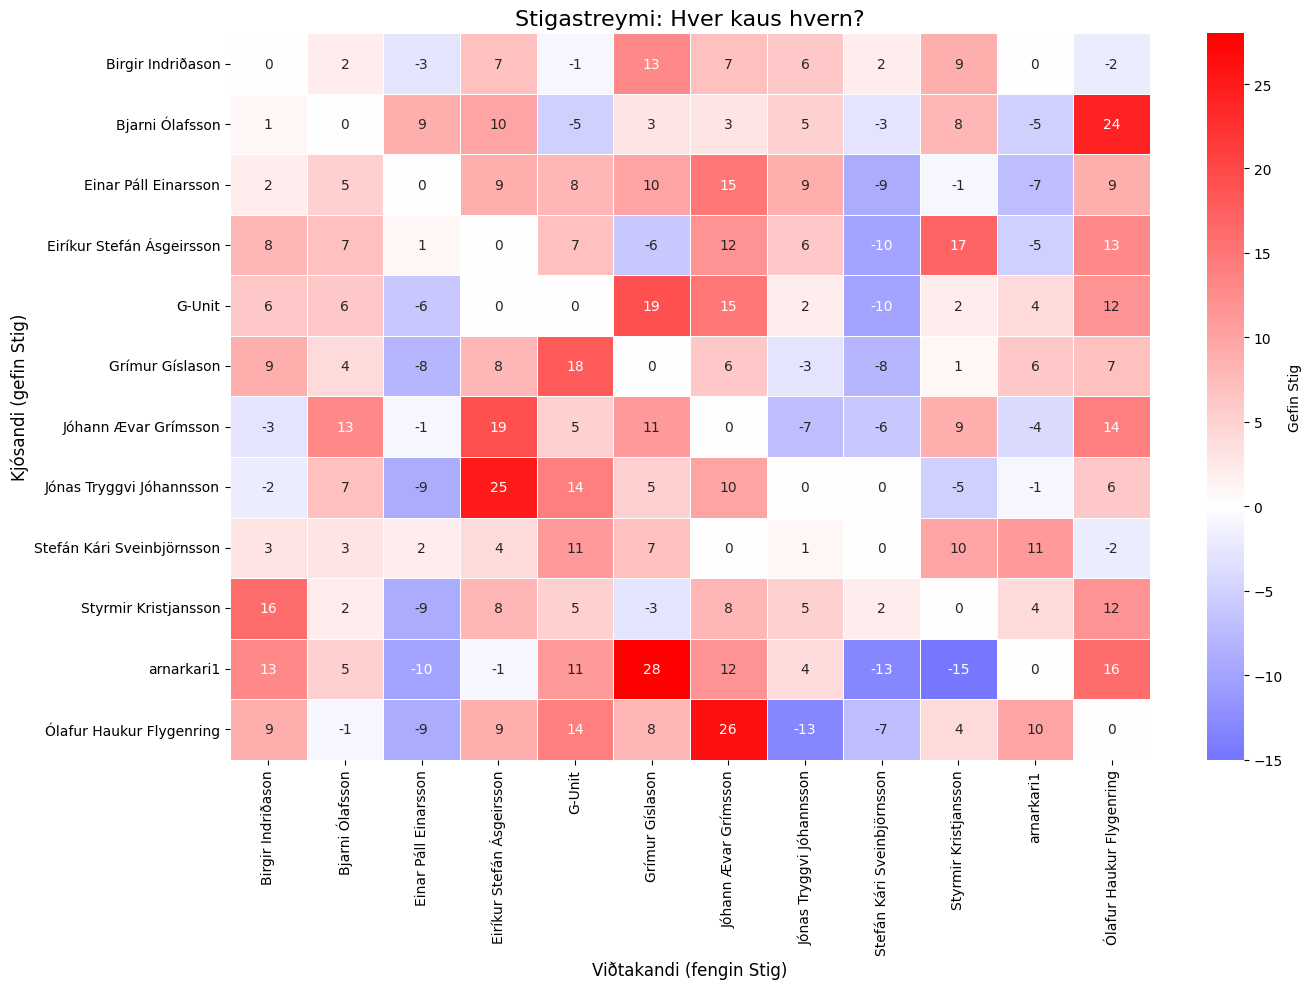

In [8]:
# @title
# 1. Undirbúa gögn fyrir flæði stiga
competitors_map = dataframes['competitors'].set_index('ID')['Name'].to_dict()

point_flow = merged_data.copy()
point_flow['Voter Name'] = point_flow['Voter ID'].map(competitors_map)
point_flow['Receiver Name'] = point_flow['Name']

# 2. Búa til töflu
pivot_table = point_flow.pivot_table(
    index='Voter Name',
    columns='Receiver Name',
    values='Points Assigned',
    aggfunc='sum'
).fillna(0)

# 3. Teikna hitakort
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='bwr',
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Gefin Stig'}
)

plt.title('Stigastreymi: Hver kaus hvern?', fontsize=16)
plt.xlabel('Viðtakandi (fengin Stig)', fontsize=12)
plt.ylabel('Kjósandi (gefin Stig)', fontsize=12)
plt.tight_layout()
plt.show()

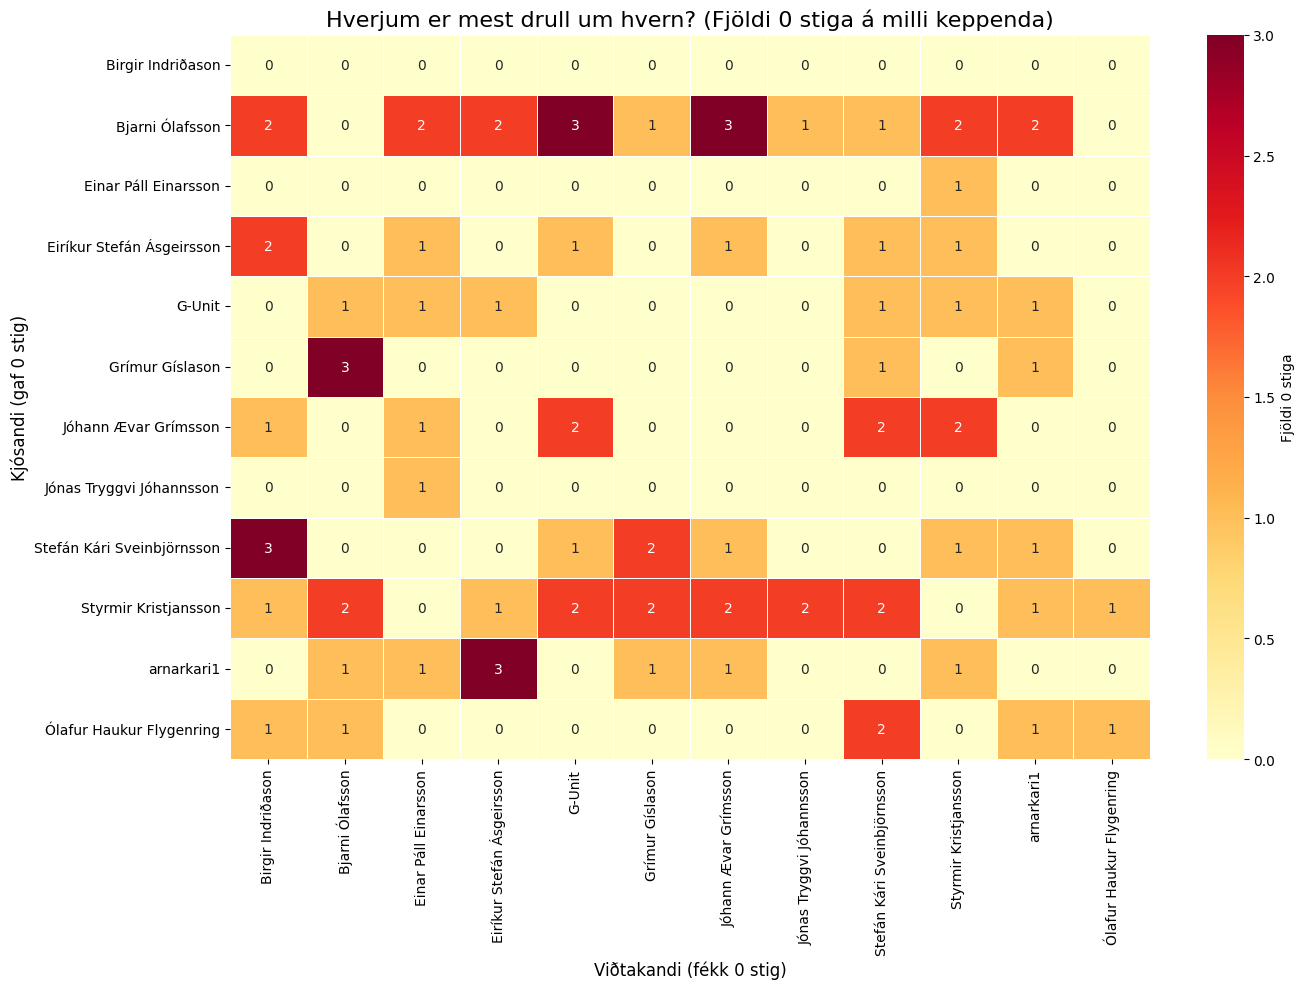

In [9]:
# @title
# 1. Sía gögn þar sem stig eru 0
zero_flow = merged_data[merged_data['Points Assigned'] == 0].copy()
zero_flow['Kjósandi'] = zero_flow['Voter ID'].map(competitors_map)
zero_flow['Viðtakandi'] = zero_flow['Name']

# 2. Búa til töflu sem telur skiptin
indifference_matrix = zero_flow.pivot_table(
    index='Kjósandi',
    columns='Viðtakandi',
    values='Points Assigned',
    aggfunc='size'
).fillna(0)

# Tryggja að allir keppendur séu með, líka þeir sem aldrei gáfu/fengu 0
all_competitors = sorted(list(competitors_map.values()))
indifference_matrix = indifference_matrix.reindex(index=all_competitors, columns=all_competitors, fill_value=0)

# 3. Teikna hitakort
plt.figure(figsize=(14, 10))
sns.heatmap(
    indifference_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=.5,
    cbar_kws={'label': 'Fjöldi 0 stiga'}
)

plt.title('Hverjum er mest drull um hvern? (Fjöldi 0 stiga á milli keppenda)', fontsize=16)
plt.xlabel('Viðtakandi (fékk 0 stig)', fontsize=12)
plt.ylabel('Kjósandi (gaf 0 stig)', fontsize=12)
plt.tight_layout()
plt.show()

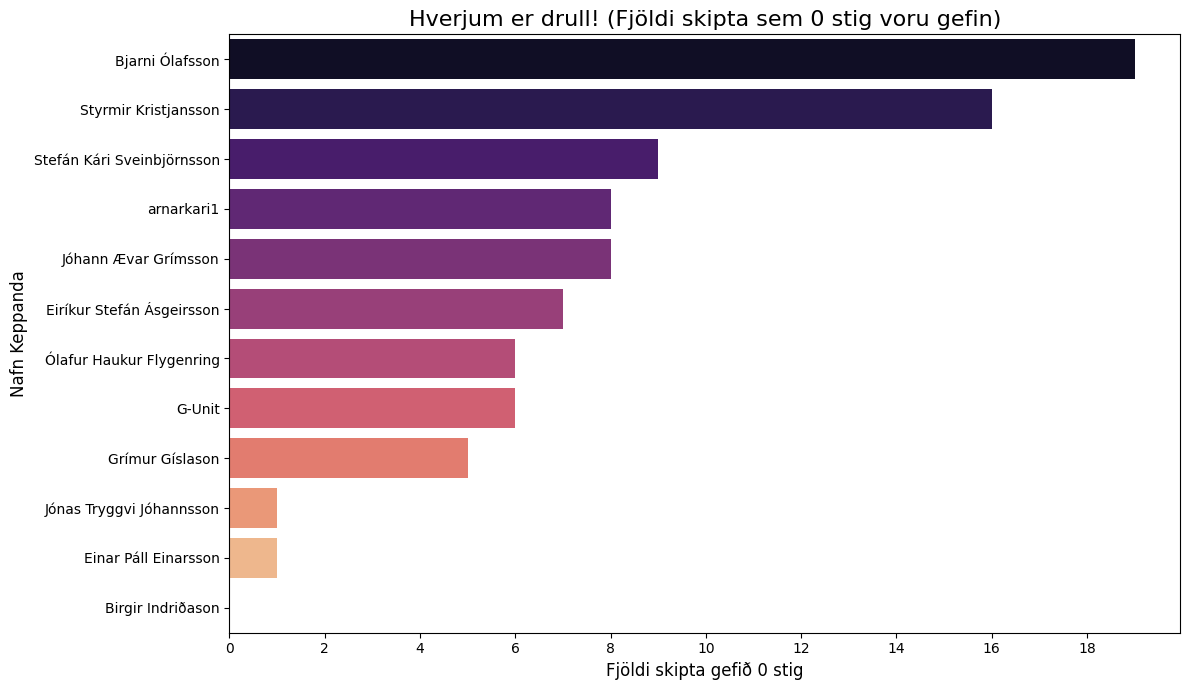

In [10]:
# @title
# 1. Sía gögn þar sem stig eru 0 og telja fyrir hvern kjósanda
zero_votes = merged_data[merged_data['Points Assigned'] == 0].copy()
zero_votes['Kjósandi'] = zero_votes['Voter ID'].map(competitors_map)

indifference_counts = zero_votes['Kjósandi'].value_counts().reset_index()
indifference_counts.columns = ['Nafn', 'Fjöldi núllstiga']

# Tryggja að allir keppendur komi fram, líka þeir með 0 núllstig
all_names = pd.DataFrame(list(competitors_map.values()), columns=['Nafn'])
indifference_counts = pd.merge(all_names, indifference_counts, on='Nafn', how='left').fillna(0)
indifference_counts = indifference_counts.sort_values(by='Fjöldi núllstiga', ascending=False)

# 2. Teikna grafið
plt.figure(figsize=(12, 7))
sns.barplot(
    data=indifference_counts,
    x='Fjöldi núllstiga',
    y='Nafn',
    palette='magma',
    hue='Nafn',
    legend=False
)

# 3. Titlar og stillingar
plt.title('Hverjum er drull! (Fjöldi skipta sem 0 stig voru gefin)', fontsize=16)
plt.xlabel('Fjöldi skipta gefið 0 stig', fontsize=12)
plt.ylabel('Nafn Keppanda', fontsize=12)

# Festa heiltölur á x-ás
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

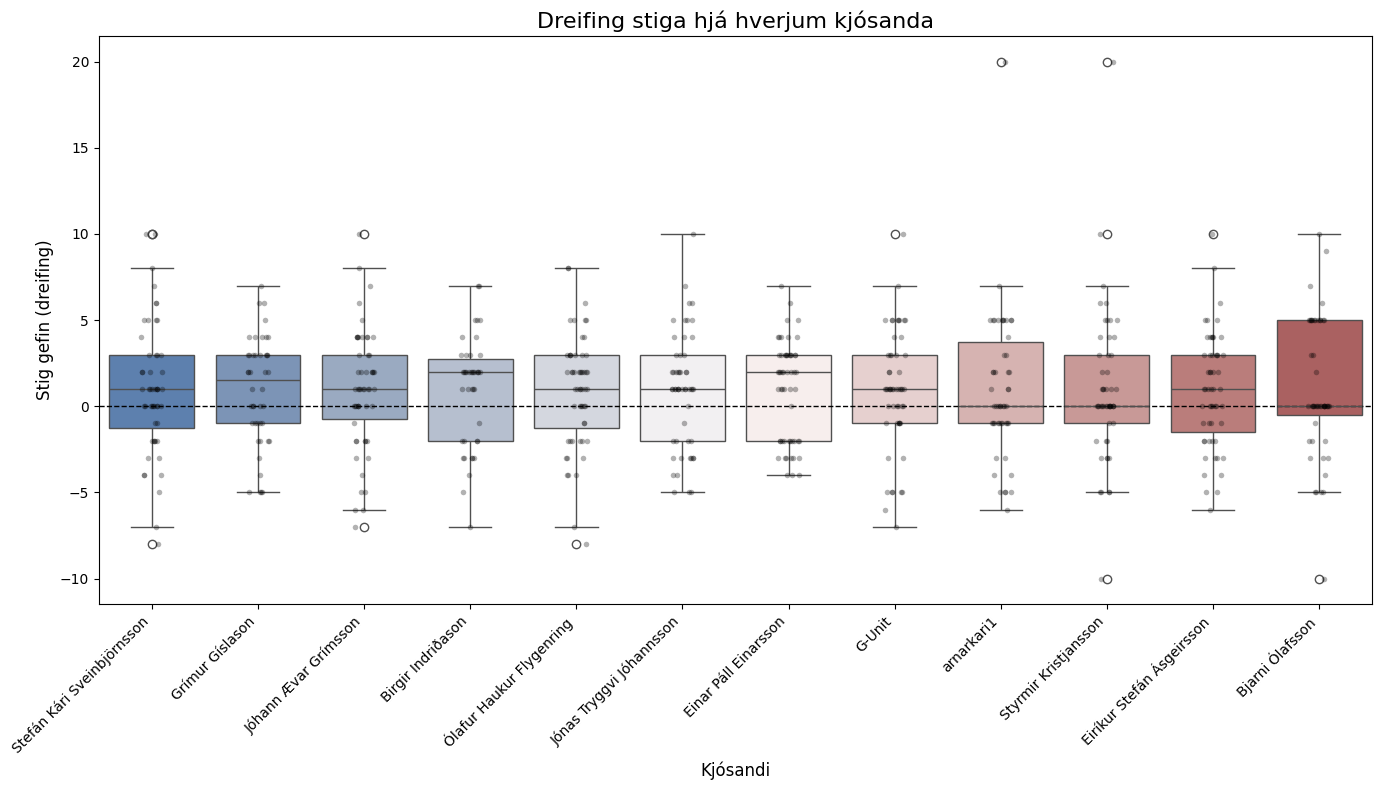

In [11]:
# @title
# 1. Undirbúa gögn fyrir dreifingu stiga
voter_stats = merged_data.copy()
voter_stats['Voter Name'] = voter_stats['Voter ID'].map(competitors_map)

# 2. Teikna kassarit (Boxplot)
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=voter_stats,
    x='Voter Name',
    y='Points Assigned',
    palette='vlag',
    hue='Voter Name',
    legend=False
)

# 3. Bæta við punktum til að sjá nákvæma dreifingu (Stripplot)
sns.stripplot(
    data=voter_stats,
    x='Voter Name',
    y='Points Assigned',
    color='black',
    alpha=0.3,
    size=4
)

plt.title('Dreifing stiga hjá hverjum kjósanda', fontsize=16)
plt.xlabel('Kjósandi', fontsize=12)
plt.ylabel('Stig gefin (dreifing)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', lw=1, ls='--')

plt.tight_layout()
plt.show()

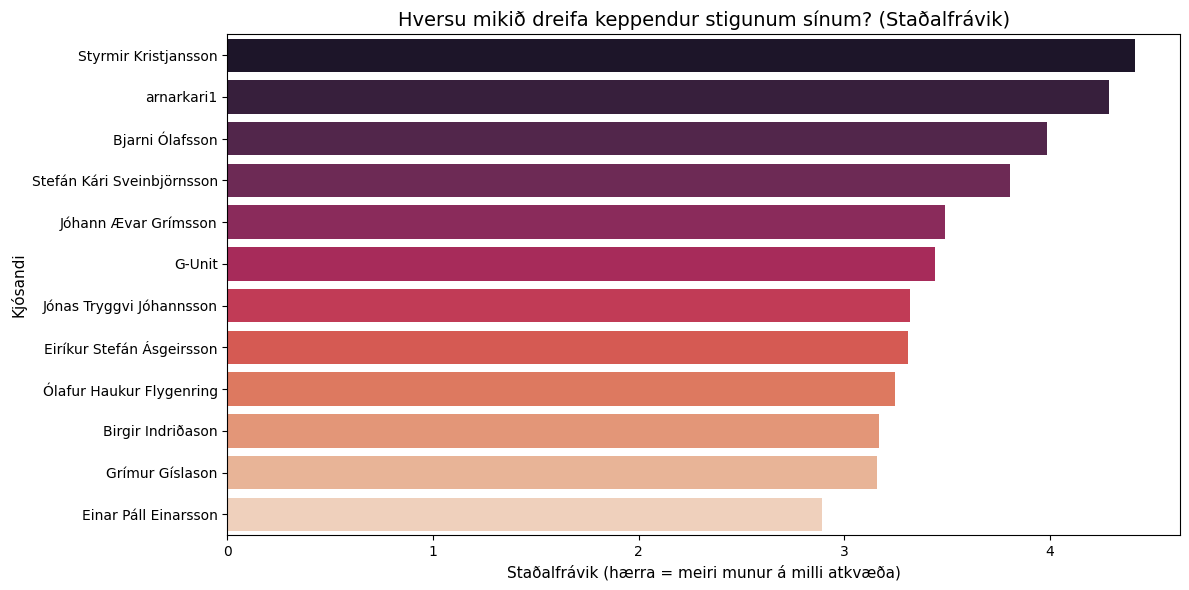

In [12]:
# @title
# 4. Reikna staðalfrávik stiga hjá hverjum og einum (mælikvarði á 'meanness/goodness')
voter_spread = voter_stats.groupby('Voter Name')['Points Assigned'].std().reset_index().rename(columns={'Points Assigned': 'Staðalfrávik'})
voter_spread = voter_spread.sort_values(by='Staðalfrávik', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=voter_spread,
    x='Staðalfrávik',
    y='Voter Name',
    palette='rocket',
    hue='Voter Name',
    legend=False
)

plt.title('Hversu mikið dreifa keppendur stigunum sínum? (Staðalfrávik)', fontsize=14)
plt.xlabel('Staðalfrávik (hærra = meiri munur á milli atkvæða)', fontsize=11)
plt.ylabel('Kjósandi', fontsize=11)

plt.tight_layout()
plt.show()

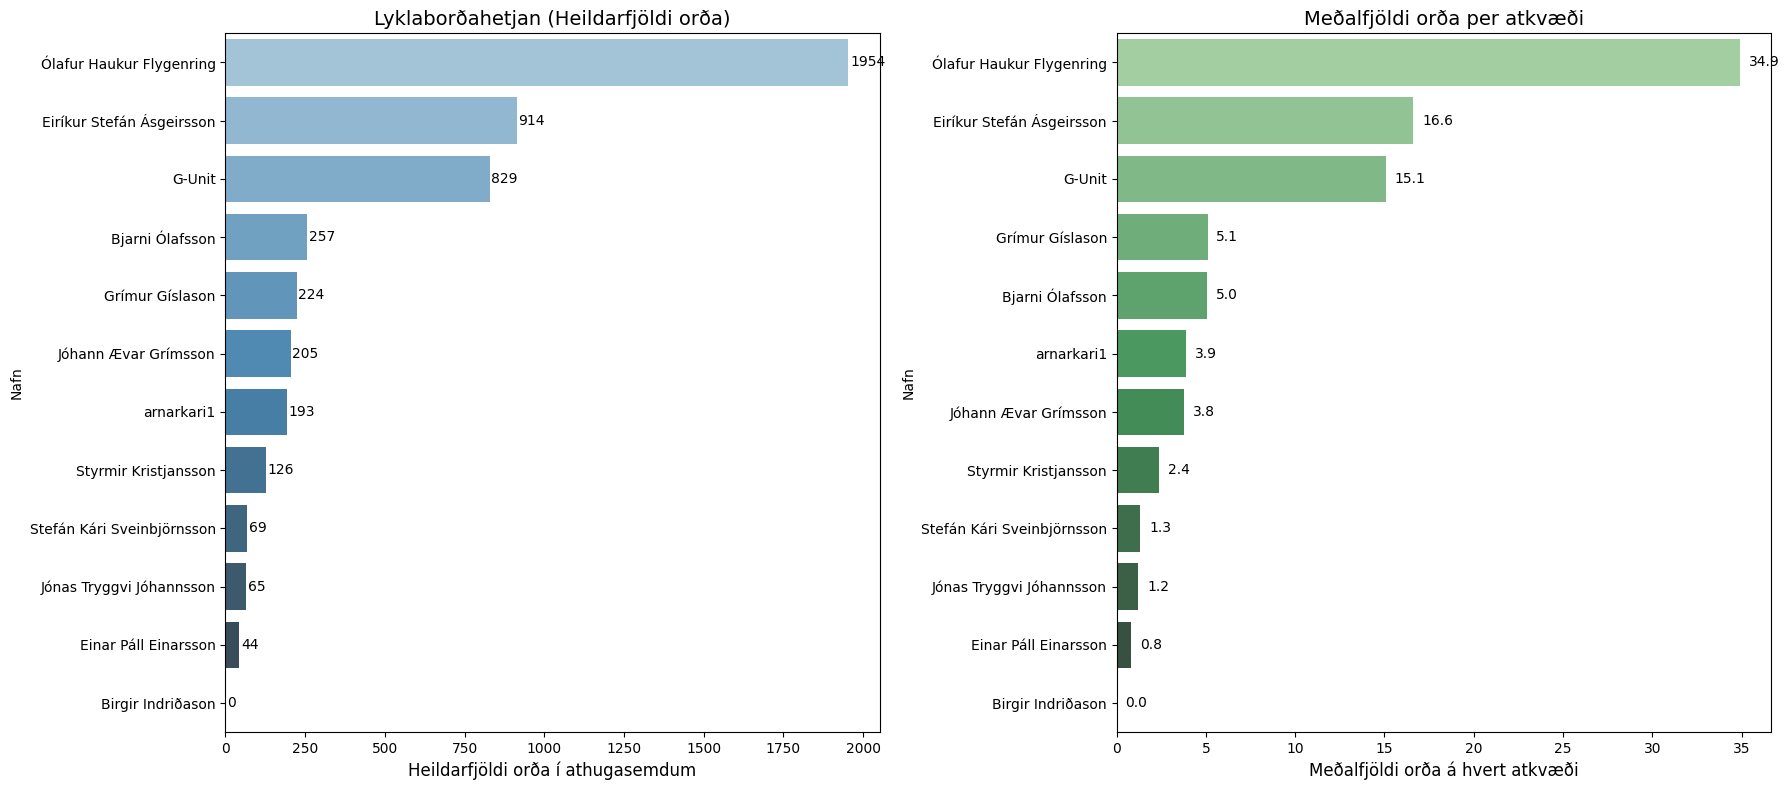

In [13]:
# @title
# 1. Undirbúa gögn og telja orð í athugasemdum
votes_with_comments = dataframes['votes'].copy()
votes_with_comments['Kjósandi'] = votes_with_comments['Voter ID'].map(competitors_map)

# Telja orð (meðhöndlum NaN sem tóman streng)
votes_with_comments['Orðafjöldi'] = votes_with_comments['Comment'].fillna('').apply(lambda x: len(str(x).split()))

# 2. Reikna tölfræði fyrir hvern keppanda
voter_comment_stats = votes_with_comments.groupby('Kjósandi')['Orðafjöldi'].agg(['sum', 'mean']).reset_index()
voter_comment_stats.columns = ['Nafn', 'Heildarfjöldi orða', 'Meðalfjöldi orða']
voter_comment_stats = voter_comment_stats.sort_values(by='Heildarfjöldi orða', ascending=False)

# 3. Teikna grafið (tvöföld mynd)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Vinstra graf: Heildarfjöldi orða
bar1 = sns.barplot(
    data=voter_comment_stats,
    x='Heildarfjöldi orða',
    y='Nafn',
    palette='Blues_d',
    ax=ax1,
    hue='Nafn',
    legend=False
)
# Bæta við tölum
for p in ax1.patches:
    width = p.get_width()
    ax1.text(width + 5, p.get_y() + p.get_height()/2, f'{int(width)}', va='center')

ax1.set_title('Lyklaborðahetjan (Heildarfjöldi orða)', fontsize=14)
ax1.set_xlabel('Heildarfjöldi orða í athugasemdum', fontsize=12)

# Hægra graf: Meðalfjöldi orða á hvert atkvæði
voter_comment_stats_mean = voter_comment_stats.sort_values(by='Meðalfjöldi orða', ascending=False)
bar2 = sns.barplot(
    data=voter_comment_stats_mean,
    x='Meðalfjöldi orða',
    y='Nafn',
    palette='Greens_d',
    ax=ax2,
    hue='Nafn',
    legend=False
)
# Bæta við tölum
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}', va='center')

ax2.set_title('Meðalfjöldi orða per atkvæði', fontsize=14)
ax2.set_xlabel('Meðalfjöldi orða á hvert atkvæði', fontsize=12)

plt.tight_layout()
plt.show()